All neccessary packages and directories

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
import os
import sys
import getpass as _getpass

# Set Username
user_name=_getpass.getuser()

if user_name=='fabioballoni':

    sys.path.append('/Users/%s/Development/repos/risk/risk_pylibrary/'%user_name)
    sys.path.append('/Users/%s/Development/repos/risk/'%user_name)
    
elif user_name=='victoriadobryashkina':

    sys.path.append('/Users/%s/Documents/Coding/repos/risk_pylibrary'%user_name)
    sys.path.append('/Users/%s/Documents/Coding/repos'%user_name)


from tools.snowflake_db import db_connection as db
from risk_pylibrary.risk_analytics import risk_engines as re

np.random.seed(17)

**1. Investigate Existent Stressed VaR Function**

Set up all data. Create random sets

In [5]:

#random returns
rets=pd.DataFrame(np.random.randn(500, 5) * 0.01)

#random weights 
N = rets.shape[1]
wgts = np.random.dirichlet(np.ones(N), size=1)

Get Portfolio Data

In [6]:
from risk_pylibrary.projects.caracalla import caracalla_portfolio as c_port
from datetime import date

accounts=['tiberius','caligula','caracalla','trajan']
risk_engines = {'hs': {'qtls': [0.001],'window': 250,'verbose': 1}}
value_date=date(2025,6,30)

# Set Outputs
out_wgts=pd.DataFrame()
out_pf_rets=pd.DataFrame()

for account in accounts:
    out_dict_tmp = c_port.get_caracalla_portfolio(calc_rf_port=True,calc_risk=False,calc_pnl_report=False,value_date=value_date,risk_engines=risk_engines,rf_mapping_new=True,force_rf=True, new_pf_engine=True, live_trading=False, account=account)
    
    tmp_rf=out_dict_tmp['rf_portfolio']
    tmp_rf=tmp_rf.reset_index()[['risk_factor','weight']].groupby('risk_factor').sum()
    tmp_rf.columns=[account]
    out_wgts=pd.concat([out_wgts,tmp_rf],axis=1)

    # portfolio return
    tmp_pf_ret=out_dict_tmp['rf_portfolio_returns']
    tmp_pf_ret.columns=[account]
    out_pf_rets=pd.concat([out_pf_rets,tmp_pf_ret],axis=1)

    # Risk Factor Returns
    rets=out_dict_tmp['returns']
    rets = rets.loc[:,~rets.columns.duplicated()].copy()
    

	 Fetching Positions with New Portfolio Engine for 2025-06-30
	 ********** Initialising Risk Factor Mapping Engine **********
		 1. Retrieving GenericSecurity Information
		 2. Retrieving Equity Country Mapping
		 Mapping Equity Risk Factors
			 Querying TEAMS_PRD.RISK_DATA.RISK_FACTOR_MAPPING
			 Creating Mapping Dictionary
		 3. Mapping Equity Risk Factors
		 4. Mapping Bond Risk Factors


	 ***** Retrieving Stored Yields Data *****
	
 ***** Retrieving Stored OAS Data *****
	
 ***** WARNING: 0 instruments could not be mapped *****
		 5. Calculating Bond Analytics
	 Calculating Macaulay Duration
	 Calculating Modified Duration
	 Calculating Convexity
		 6. Mapping ETF Risk Factors
		 7. Mapping Residual Risk Factors
	 Fetching Positions with New Portfolio Engine for 2025-06-30
	 ********** Initialising Risk Factor Mapping Engine **********
		 1. Retrieving GenericSecurity Information
		 2. Retrieving Equity Country Mapping
		 Mapping Equity Risk Factors
			 Querying TEAMS_PRD.RISK_DAT

Calculate Stressed VaR

In [7]:
out_wgts

,tiberius,caligula,caracalla,trajan
risk_factor,,,,
fx_eurusd,-1.000000,0.488250,0.721904,0.662116
msci_world,-1.000000,0.488250,0.721904,0.662116
global_agg_bond,NaN,0.511750,0.278096,0.337884


In [8]:
stressedVaR = re.stressed_vaR(rets_orig=rets,wgts=out_wgts.tiberius.fillna(0), engine='hs')


     ------------------------------------------------------------
               Portfolio Stressed VaR Calculation
     ------------------------------------------------------------
      Model: 
			hs

      Model Inputs:
 			window: 250
			qtls: [0.05, 0.01, 0.001]
			holding_period: 1
			decay: 0.94
			distr: norm
			verbose: True

      Series Start and End:
 			Start 2008-01-01, End 2025-06-30
     ------------------------------------------------------------

Initializing Historical Simulation Model for Value at Risk Calculation with 4536 windows
			 Calculated 250 windows
			 Calculated 500 windows
			 Calculated 750 windows
			 Calculated 1000 windows
			 Calculated 1250 windows
			 Calculated 1500 windows
			 Calculated 1750 windows
			 Calculated 2000 windows
			 Calculated 2250 windows
			 Calculated 2500 windows
			 Calculated 2750 windows
			 Calculated 3000 windows
			 Calculated 3250 windows
			 Calculated 3500 windows
			 Calculated 3750 windows
			 Calculated 4000 wind

In [25]:
stressedVaR.head()

,var950_1d,cvar950_1d,var990_1d,cvar990_1d,var999_1d,cvar999_1d
2008-12-16,0.032137,0.070353,0.110821,0.137033,0.149973,0.156461
2008-12-17,0.032137,0.070353,0.110821,0.137033,0.149973,0.156461
2008-12-18,0.032137,0.070353,0.110821,0.137033,0.149973,0.156461
2008-12-19,0.032137,0.070353,0.110821,0.137033,0.149973,0.156461
2008-12-22,0.032137,0.070353,0.110821,0.137033,0.149973,0.156461


Plot the results

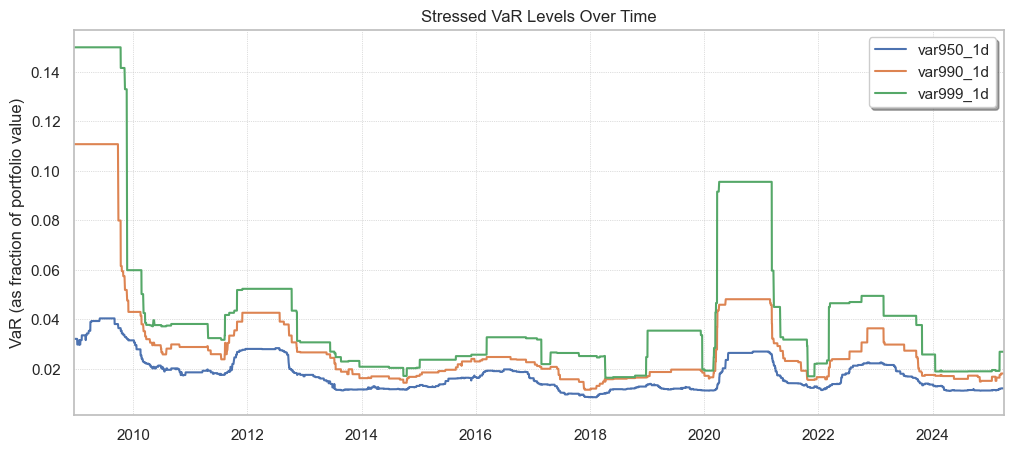

In [31]:
stressedVaR[['var950_1d', 'var990_1d', 'var999_1d']].plot(figsize=(12, 5), title='Stressed VaR Levels Over Time')
plt.ylabel('VaR (as fraction of portfolio value)')
plt.grid(True)
plt.show()


In [33]:
os.getcwd()
xl_scenarios =pd.read_excel (r'/Users/%s/Downloads/20250411_UpdateStressScenarioTable.xlsx'%user_name)


In [34]:
xl_scenarios

,Unnamed: 0,code,name,scenario_type,lookback_horizon,shock_length,shock_startdate,stress_scenario_parameter,stress_scenario_description
0,0,stress_covid19,MR - Covid19 Shock,Historical,1250,20,2020-02-26,sp500 -25%|dax -30%|nikkei225 -30%|Y...,"20 day shock period (S&P500 -25%, DA..."
1,1,stress_ftxctrash,MR - Cryptocurrency FTX Crash 2022,Historical,1250,5,2022-11-06,btc_eur -25%|eth_eur -25%,1 day shock period (BTC Shock Down -...
2,2,stress_usdcrash,MR - USD Crash,Hypothetical,1250,10,2023-07-01,fx_eurusd -10%,5 day shock period (USD/EUR Shock Do...
3,3,stress_fincrisis,MR - Financial Crisis 08/09,Historical,1250,125,2008-09-15,YIELD_US_10Y 350bps|YIELD_US_3Y 150b...,250 day shock period (Gov. Short Rat...
4,4,stress_emudebt,MR - European Debt Crisis 2012,Historical,1250,90,2012-01-15,YIELD_IT_3Y -300bps|YIELD_IT_10Y -60...,90 day shock period (Gov. Short Rate...
5,5,stress_globalinflation,MR - Global Rise Inflation,Hypothetical,1250,120,2022-03-01,YIELD_IT_3Y -200bps|YIELD_IT_10Y -40...,120 day shock period (US CPI Shock U...


Define rolling VaR

In [57]:
def stressed_var_rolling(
    rets_orig,
    wgts=None,  # Optional 
    engine='hs',
    fmt_engine={},
    threshold=0.01,
    verbose=False
):
    import pandas as pd
    from risk_pylibrary.risk_analytics import risk_engines as re

    results = []
    window = fmt_engine.get('window', 250)

    for i in range(window, len(rets_orig)):
        rets_window = rets_orig.iloc[i - window:i + 1]
        date = rets_orig.index[i]

        try:
            result = re.stressed_vaR(
                rets_orig=rets_window,
                wgts=wgts, 
                engine=engine,
                fmt_engine=fmt_engine,
                verbose=verbose
            )
        except Exception as e:
            print(f"[!] Error calculating VaR on {date} with engine {engine}: {e}")
            continue

        row = {'date': date}
        for col in result.columns:
            value = result.loc[result.index[-1], col]
            row[col] = value
            if col.startswith('var'):
                level = col.replace("var", "").replace("_1d", "")
                row[f"breach{level}"] = value > threshold

        results.append(row)

    return pd.DataFrame(results)#.set_index('date')


Wrapper to run across all scenarios in xl_scenarios

In [51]:
def run_all_scenario_svar(rets_full, wgts, scenario_df, fmt_engine_base, threshold=0.01):
    """
    Runs rolling stressed_vaR for each scenario and engine type.
    Supports any engine implemented in the original stressed_vaR().
    """
    out = {}

    scenario_type_map = {
        'Historical': 'hs',
        'Hypothetical': 'gjr'  # extend as needed!! in the scenarios only those two, might be more
    }

    for _, row in scenario_df.iterrows():
        code = row['code']
        start_date = row['shock_startdate'].date()
        length = int(row['shock_length'])
        scenario_type = row['scenario_type']
        engine = scenario_type_map.get(scenario_type, 'hs')

        window = fmt_engine_base.get('window', 250)
        rets_window = rets_full.loc[start_date:]
        rets_window = rets_window.iloc[:length + window]

        if len(rets_window) < length + window:
            print(f"[!] Skipping {code}: not enough data for {window + length} days from {start_date}")
            continue

        print(f"Running rolling stressed_vaR for {code} ({scenario_type}) using engine: {engine}")

        result = stressed_var_rolling(
            rets_orig=rets_window,
            wgts=wgts,
            engine=engine,
            fmt_engine={**fmt_engine_base, 'window': window},
            threshold=threshold,
            verbose=False
        )

        out[code] = result

    return out



Take 99% and 99.9% 1-day VaR

In [45]:
tmp_pf_ret

,trajan
ddate,
2008-01-01,0.000055
2008-01-02,-0.004076
2008-01-03,0.001810
2008-01-04,-0.025723
2008-01-07,0.000536
...,...
2025-03-25,0.007996
2025-03-26,-0.010600
2025-03-27,0.001057


In [48]:
out_pf_rets[['tiberius']].loc[date(2020,2,26)]

tiberius   -0.010735
Name: 2020-02-26, dtype: float64

In [59]:
results = run_all_scenario_svar(rets_full=out_pf_rets[['tiberius']],
                                wgts=out_wgts.tiberius.values,
                                scenario_df=xl_scenarios,
                                fmt_engine_base={'qtls': [0.01,0.001], 'holding_period': 1, 'window': 250},
                                threshold=0.01)

Running rolling stressed_vaR for stress_covid19 (Historical) using engine: hs

     ------------------------------------------------------------
               Portfolio Stressed VaR Calculation
     ------------------------------------------------------------
      Model: 
			hs

      Model Inputs:
 			qtls: [0.01, 0.001]
			holding_period: 1
			window: 250
			decay: 0.94
			distr: norm
			verbose: True

      Series Start and End:
 			Start 2020-02-26, End 2021-02-11
     ------------------------------------------------------------
[!] Error calculating VaR on 2021-02-11 with engine hs: Unable to coerce to Series, length must be 1: given 20

     ------------------------------------------------------------
               Portfolio Stressed VaR Calculation
     ------------------------------------------------------------
      Model: 
			hs

      Model Inputs:
 			qtls: [0.01, 0.001]
			holding_period: 1
			window: 250
			decay: 0.94
			distr: norm
			verbose: True

      Series Sta

KeyError: datetime.date(2022, 11, 6)

In [56]:
results

NameError: name 'results' is not defined

Define max VaR per scenario

In [151]:
def max_var_per_scenario(results_dict, quantile=0.01):
    """
    Extracts the maximum VaR value for each scenario from the results dictionary.

    Parameters:
        results_dict : dict
            Dictionary with scenario name as key and result DataFrame as value.
        quantile : float
            Quantile level used in the VaR column (e.g. 0.01 for 99%).

    Returns:
        DataFrame with max VaR value per scenario.
    """
    var_col = f'var{int((1 - quantile) * 1000)}_1d'
    summary = []

    for scenario, df in results_dict.items():
        if var_col in df.columns and not df.empty:
            max_var = df[var_col].max()
            summary.append({'scenario': scenario, 'max_var': round(max_var, 6)})
        else:
            summary.append({'scenario': scenario, 'max_var': None})

    return pd.DataFrame(summary).sort_values(by='max_var', ascending=False)


In [173]:
max_var_summary = max_var_per_scenario(results, quantile=0.001)
print(max_var_summary)


                 scenario   max_var
4  stress_globalinflation  0.010866
2        stress_fincrisis  0.010160
1        stress_ftxctrash  0.009375
0          stress_covid19  0.008963
3          stress_emudebt  0.008302


Define flattening results function, dict to dataframe

In [ ]:
def flatten_results(results_dict):
    dfs = []
    for scenario, df in results_dict.items():
        if not df.empty:
            df_copy = df.copy()
            df_copy["scenario"] = scenario
            dfs.append(df_copy)
    return pd.concat(dfs).reset_index()


In [ ]:
# Flatten the dict of DataFrames
all_results_df = flatten_results(results)

# Export to Excel to make a pivot or cross-check
all_results_df.to_excel('/Users/victoriadobryashkina/Downloads/stressed_var_all_scenarios.xlsx', index=False)


Define breaches counter function

In [164]:
def count_breaches_flat(results_df, quantile=0.01):
    """
    Counts how many times the rolling VaR breached the threshold per scenario from a flat DataFrame.

    Parameters:
    - results_df: Flattened DataFrame (with 'scenario' column)
    - quantile: VaR quantile used (e.g. 0.01 for 99%)

    Returns:
    - DataFrame with scenario name, breach count, and total days
    """
    col_flag = f'breach{int(1000 * (1 - quantile))}'

    if col_flag not in results_df.columns:
        raise ValueError(f"Breach column '{col_flag}' not found in the DataFrame.")

    summary = (
        results_df
        .groupby('scenario')
        .agg(
            breach_count=(col_flag, 'sum'),
            total_days=(col_flag, 'count')
        )
        .reset_index()
    )
    summary['breach_rate'] = (summary['breach_count'] / summary['total_days'] * 100).round(2)

    return summary.sort_values(by='breach_count', ascending=False)


Define a function to check which quantiles were in the sample (which we defined above)

In [169]:
def extract_quantiles(results_dict):
    """
    Scans all scenario result DataFrames to find which VaR quantile levels were calculated.
    Returns a dictionary: scenario → list of quantiles.
    """
    quantile_map = {}

    for scenario, df in results_dict.items():
        quantiles = set()
        for col in df.columns:
            if col.startswith("var") and "_1d" in col:
                level = col.replace("var", "").replace("_1d", "")
                try:
                    quantile = round(1 - int(level) / 1000, 4)
                    quantiles.add(quantile)
                except:
                    continue
        quantile_map[scenario] = sorted(quantiles)

    return quantile_map


In [196]:
extract_quantiles(results)


{'stress_covid19': [0.001, 0.01],
 'stress_ftxctrash': [0.001, 0.01],
 'stress_fincrisis': [0.001, 0.01],
 'stress_emudebt': [0.001, 0.01],
 'stress_globalinflation': [0.001, 0.01]}

In [175]:
breach_summary = count_breaches(results, quantile=0.001)
print(breach_summary)


                 scenario  breach_count  total_days  breach_rate
4  stress_globalinflation           114         120         95.0
2        stress_fincrisis            52         125         41.6
0          stress_covid19             0          20          0.0
1        stress_ftxctrash             0           5          0.0
3          stress_emudebt             0          90          0.0
